<a href="https://colab.research.google.com/github/thomsmbockchildGod/colab-git-assignment2-TM/blob/main/ai6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()
X=housing.data
Y=housing.target
df=pd.DataFrame(X,columns=housing.feature_names)
df['MedHouseVal']=housing.target
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [3]:
#Display the first few rows of the dataset to understand its structure.
print(df.head())
#Check the features and target variable. Identify which is continuous and categorical if applicable.
from sklearn.preprocessing import StandardScaler

scale=StandardScaler()

cols = ['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']

df[cols] = scale.fit_transform(df[cols])

df['MedHouseVal']=scale.fit_transform(df[['MedHouseVal']])

df

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,2.129631
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,1.314156
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,1.258693
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,1.165100
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,1.172900
...,...,...,...,...,...,...,...,...,...
20635,-1.216128,-0.289187,-0.155023,0.077354,-0.512592,-0.049110,1.801647,-0.758826,-1.115804
20636,-0.691593,-0.845393,0.276881,0.462365,-0.944405,0.005021,1.806329,-0.818722,-1.124470
20637,-1.142593,-0.924851,-0.090318,0.049414,-0.369537,-0.071735,1.778237,-0.823713,-0.992746
20638,-1.054583,-0.845393,-0.040211,0.158778,-0.604429,-0.091225,1.778237,-0.873626,-1.058608


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


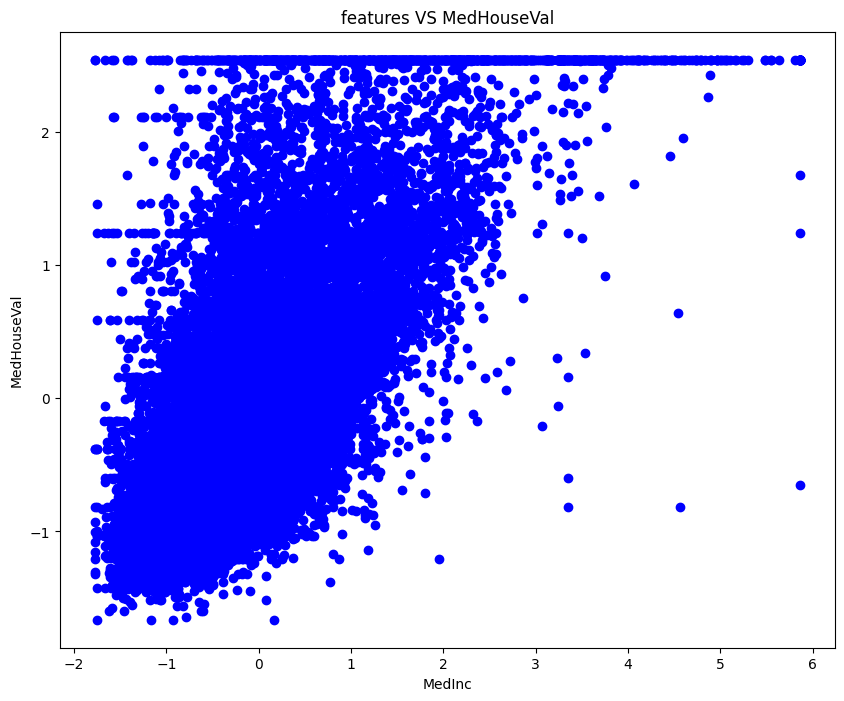

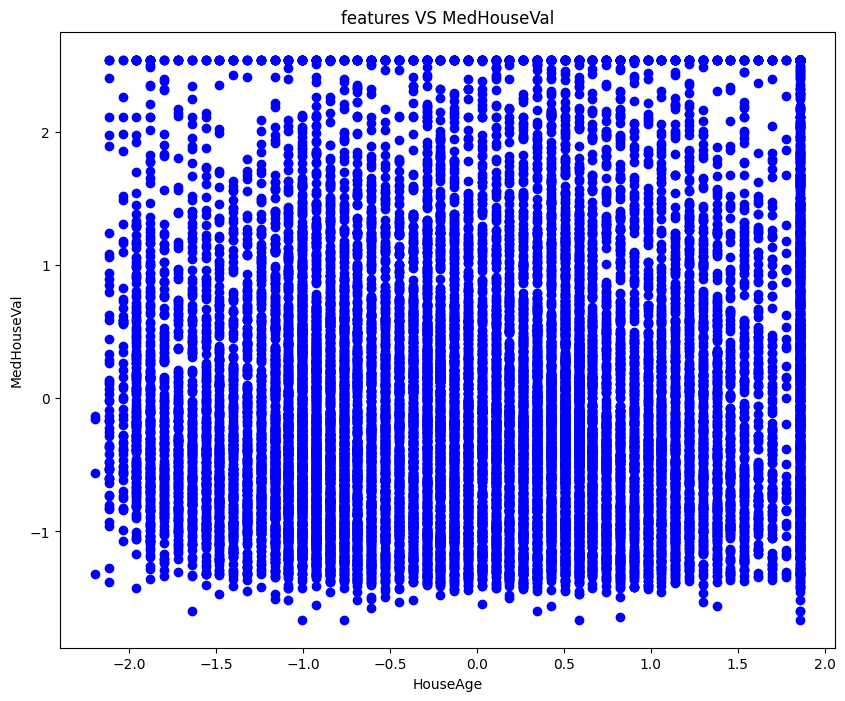

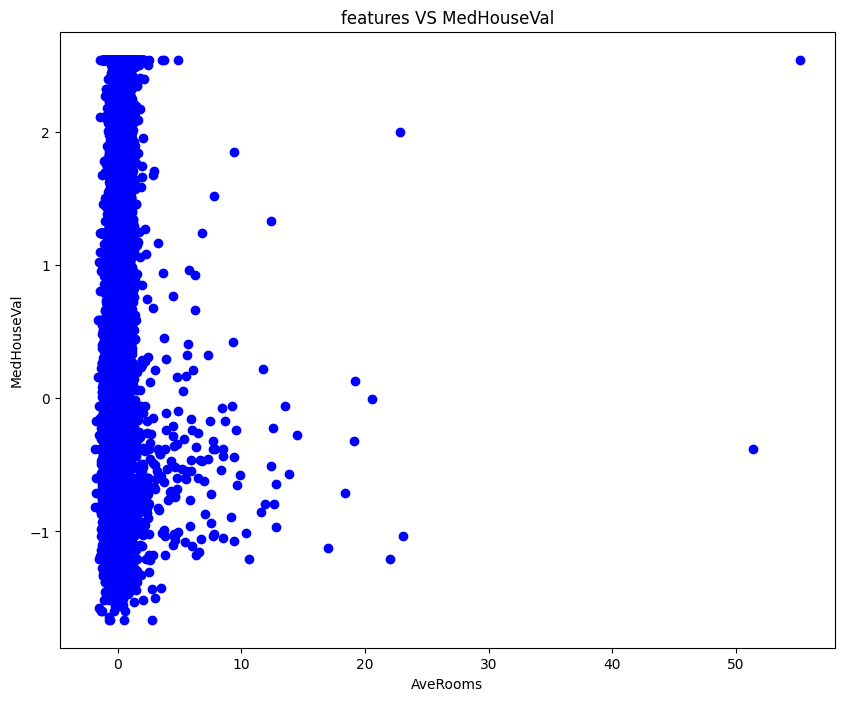

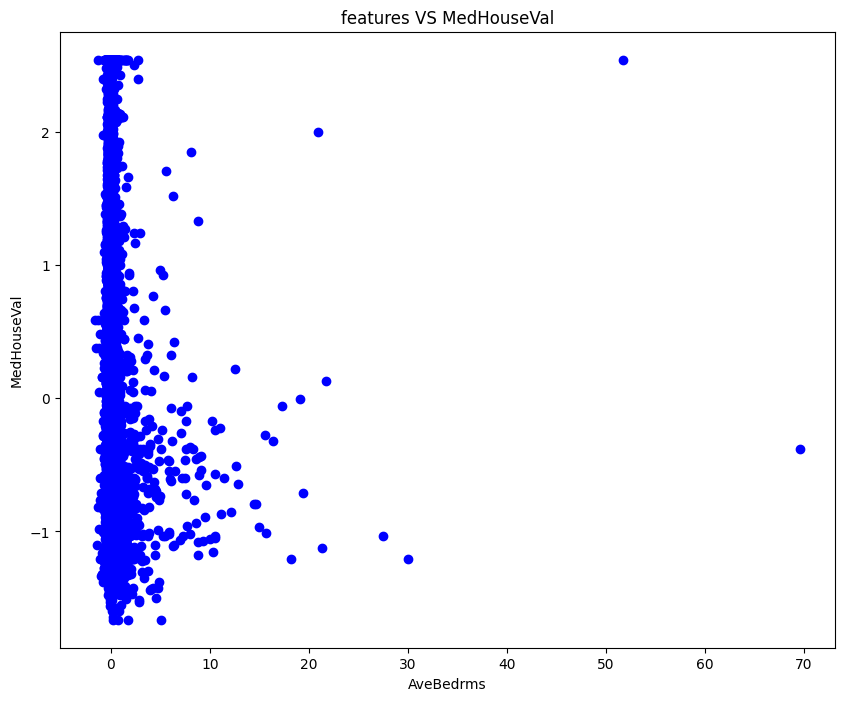

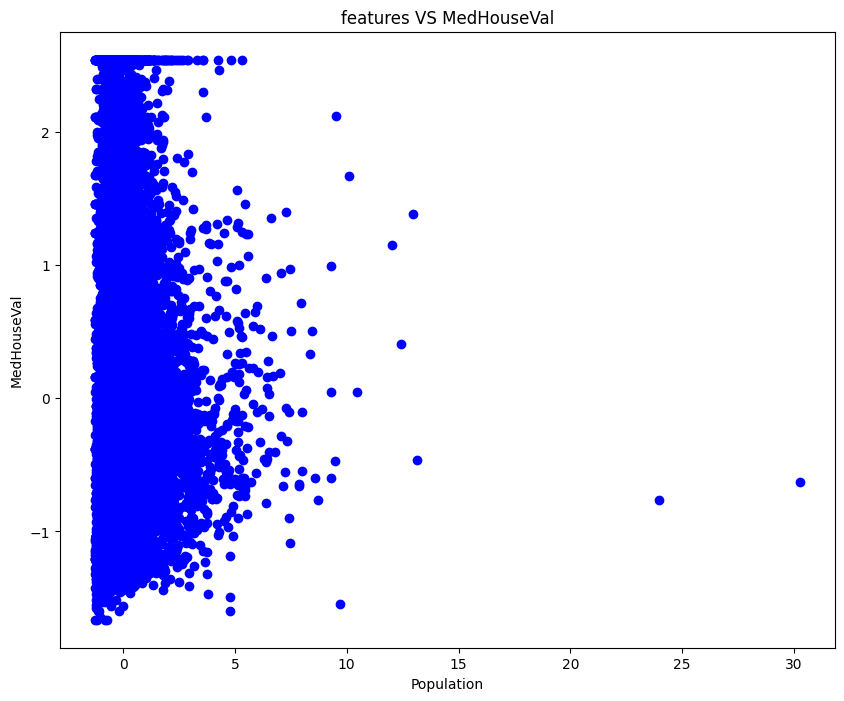

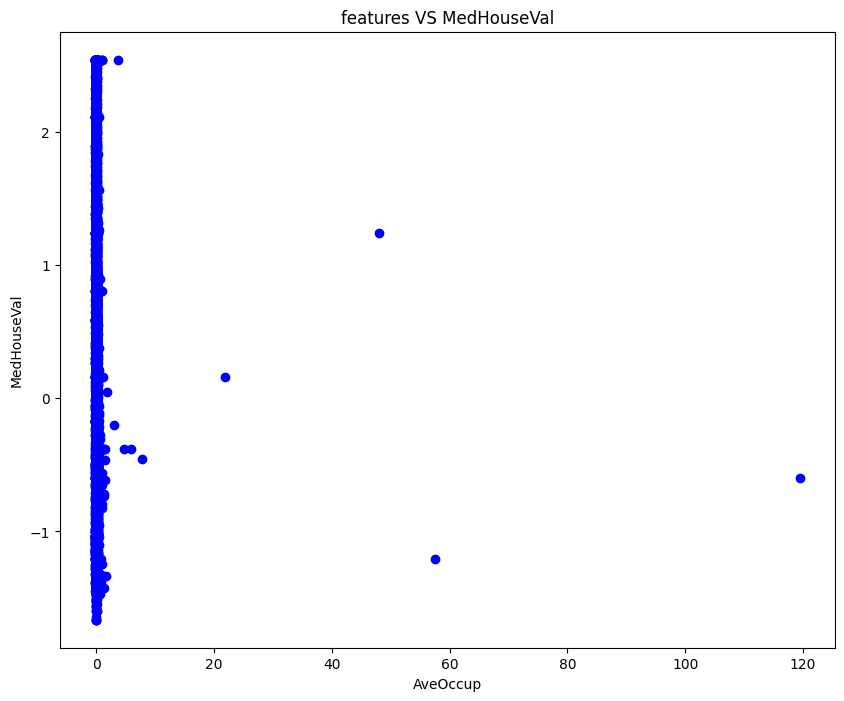

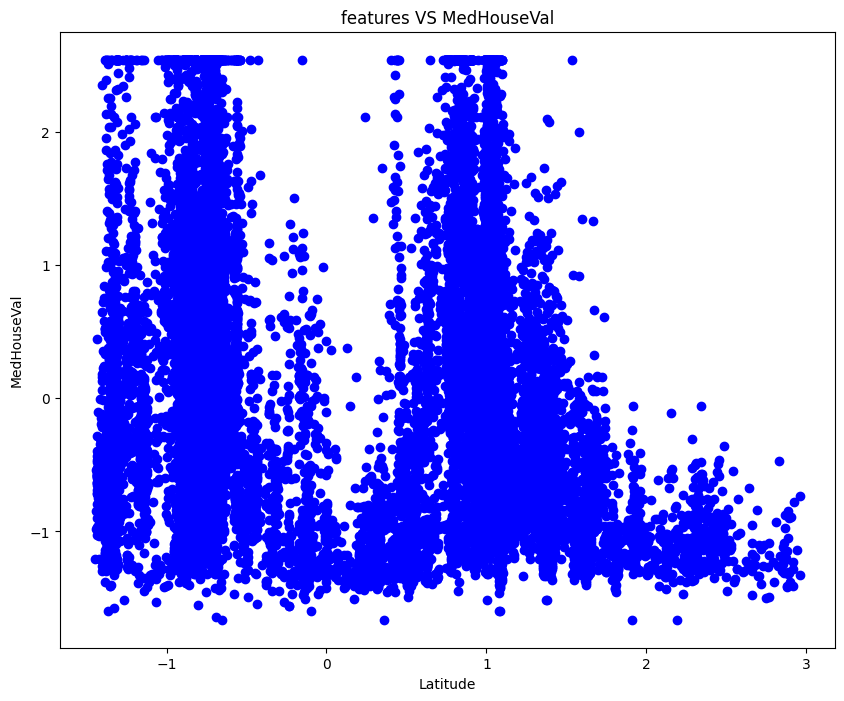

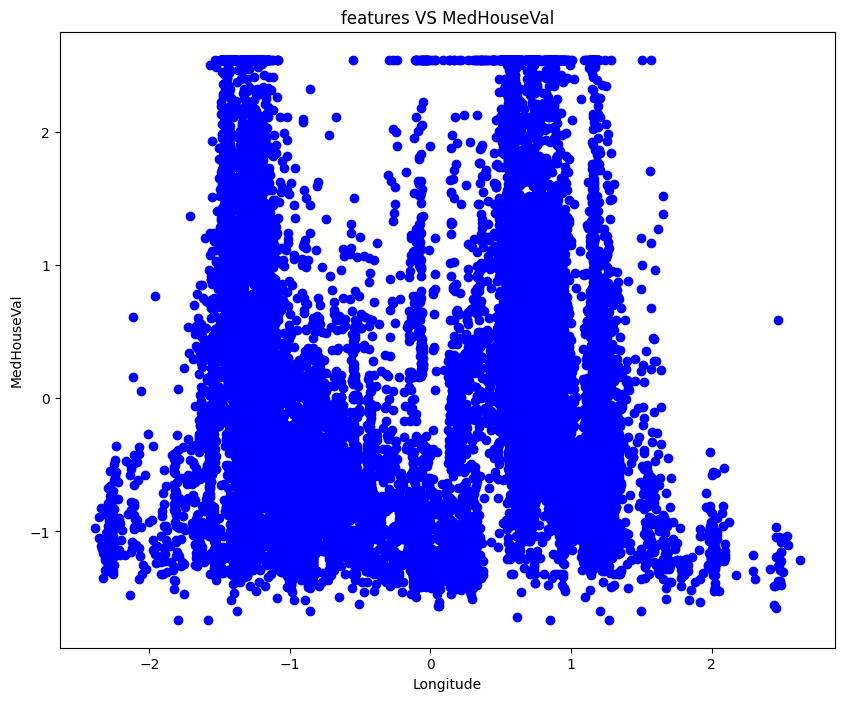

In [4]:
#EDA and Data Preprocessing:
#Check for missing/null values.
print(df.isnull().sum())
#Create a function to automate scatter plots for all features vs MedHouseVal.
def scatter_plot(features):
    plt.figure(figsize=(10,8))
    plt.scatter(df[features],df['MedHouseVal'], color='blue')
    plt.title('features VS MedHouseVal')
    plt.xlabel(features)
    plt.ylabel('MedHouseVal')
    plt.show()
#Use the function to visualize the relationships between multiple features and the target variable.
scatter_plot('MedInc')
scatter_plot('HouseAge')
scatter_plot('AveRooms')
scatter_plot('AveBedrms')
scatter_plot('Population')
scatter_plot('AveOccup')
scatter_plot('Latitude')
scatter_plot('Longitude')

In [5]:
#ML Model Training:
#Split the dataset into training and testing sets.

Y=df['MedHouseVal']

X=df.drop(columns='MedHouseVal')

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(X,Y,test_size=0.3, random_state=42)


In [6]:
#Choose an appropriate regression model and train it on the training data.

from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(x_train, y_train)

y_pred=model.predict(x_test)

In [7]:
#Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).

from sklearn.metrics import mean_squared_error, r2_score

mse=mean_squared_error(y_test, y_pred)

rmse=np.sqrt(mse)

r2=r2_score(y_test,y_pred)

print(f"model performance using mse metric: {mse}")

print(f"model performance using rmse metric: {rmse}")

print(f"model performance using r2 metric: {r2}")


model performance using mse metric: 0.39845868567194065
model performance using rmse metric: 0.6312358399773738
model performance using r2 metric: 0.5957702326061662


In [8]:
#Predict Median House Value from a new set of feature inputs.
#features = [['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup','Latitude','Longitude']]
features=np.array([[9.5,70.0,7.5,8.5,800.0,9.0,40.50,-145.30]])
print(model.predict(features))

[92.27005065]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
